<div id="container" style="position:relative;">
<div style="float:left"><h1> Python Project Sprint - Part 2 </h1></div>
<div style="position:relative; float:right">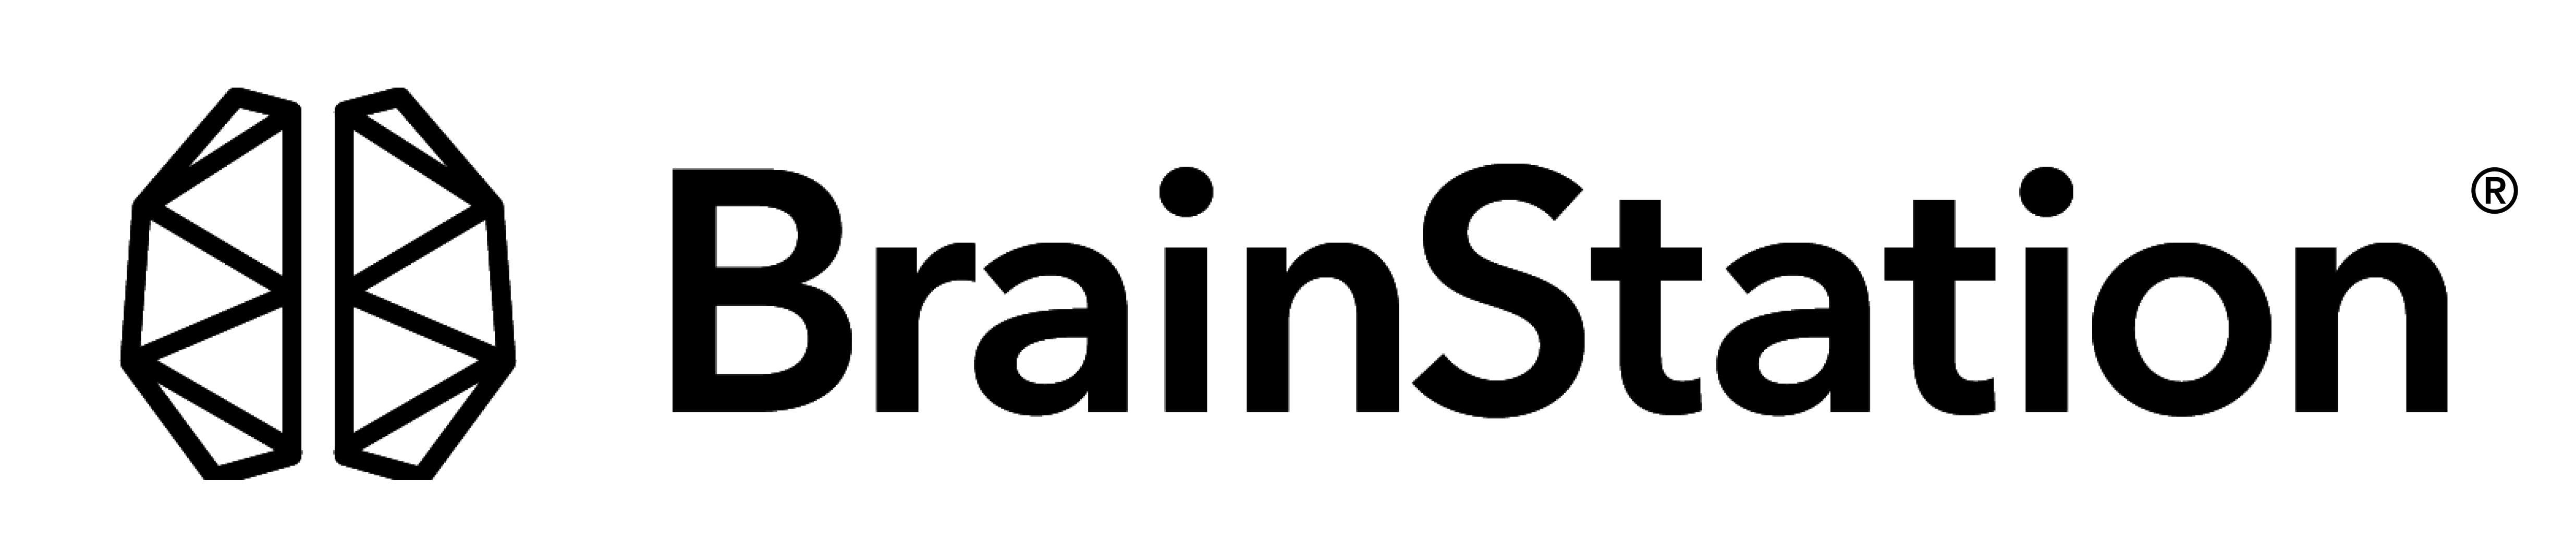
</div>
</div>


In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Below setting enables you to look at all columns in your Jupyter notebook, you'll just have to scroll to the right to see all of them in your notebook output.
pd.set_option('display.max_columns', None)

# E-commerce Dataset Overview

In this Python Project Sprint, we'll be working with a dataset derived from an online e-commerce platform. The dataset captures customer purchase records, reflecting the shopping behavior and interactions of users. It includes important details such as purchase dates, product categories, amounts spent, customer demographics, and payment methods.

This dataset is a valuable tool for:

1. Identifying popular product categories and purchase trends.
2. Analyzing customer spending patterns and behaviors.
3. Examining transaction frequency and payment preferences.
4. Building recommender systems and planning marketing strategies.

You can find the data dictionary for this dataset below.

---

## Data Dictionary

| Column Name               | Data Type | Description                                                                                     |
|---------------------------|-----------|-------------------------------------------------------------------------------------------------|
| `Customer ID`             | int       | Unique identifier for each customer.                                                            |
| `Age`                     | string    | Customer's age in years. |
| `Gender`                  | string    | Gender of the customer.                                         |
| `Item Purchased`          | string    | Name of the item purchased by the customer.                     |
| `Category`                | string    | Product category the item belongs to.                                                           |
| `Purchase Amount (USD)`   | float     | The amount of money spent on the purchase, in USD.                                              |
| `Location`                | string    | The customer's location (state or region).                          |
| `Size`                    | string    | Size of the purchased item (e.g., S, M, L).                                                     |
| `Color`                   | string    | Color of the purchased item.                                                                    |
| `Discount Applied`        | string    | Indicates if a discount was applied ("Yes" or "No").                                            |
| `Promo Code Used`         | string    | Indicates if a promotional code was used ("Yes" or "No").                                       |
| `Previous Purchases`      | float     | Number of previous purchases made by the customer.                                              |
| `Payment Method`          | string    | Payment method used by the customer.         |
| `Frequency of Purchases`  | string    | Frequency of purchases by the customer (e.g., Weekly, Monthly).                       |
| `user id`                 | float     | ID of the user associated with the purchase.    |
| `product id`              | string    | Unique identifier for the purchased product.    |
| `Interaction type`        | string    | Type of interaction the customer had with the product (e.g., purchase, view, like).             |
| `Time stamp`              | string    | Date and time of the transaction or interaction (in DD/MM/YYYY HH:MM format).                   |

# Data Visualizations

In part 1 of our Python Project Sprint, we went through the cleaning process of the e-commerce dataset and saved it as a new `csv` file. This is good practice, as data analysis pipelines are typically built in a modular way with cleaning performed first. The cleaned dataset is then stored and used in a separate module for business analysis and visualization.

We will begin by creating a Python function that can take in any raw dataset (such as our uncleaned e-commerce dataset), perform all cleaning steps, and store it for analysis. Then, we will go through the process of visualization to create charts that can help us delve into the data and extract insights from it.

## Data Cleaning Pipeline

Let's create a function to automate our data cleaning process. This function will apply all the steps we've discussed to a raw dataset and return the cleaned data. It takes five parameters:

1. `dataframe`: The input DataFrame to be cleaned.
2. `drop_duplicates`: Boolean indicating whether to remove duplicate rows.
3. `remove_missing`: Boolean indicating whether to remove rows with missing values.
4. `dropping_columns`: List of column names to be dropped.
5. `renaming_columns`: Dictionary of columns that should be renamed.

This function will streamline our data preparation workflow, making it easier to consistently clean multiple datasets.

In [251]:
# Cleaning function

def clean_dataframe(df:pd.DataFrame(), 
                    drop_duplicates:bool =True, 
                    remove_missing:bool =True, 
                    dropping_columns:list = None,
                    renaming_columns:dict={}) -> pd.DataFrame():
    """
    Cleans the given dataframe by performing the following operations:

    - Drops specified columns.
    - Removes missing values if specified.
    - Removes duplicate rows if specified.
    - Replaces ',' with '.' in the 'Age' column.
    - Replaces '\n' with '' in the 'Payment Method' column.
    - Drops columns if specified.
    - Renames columns if specified.
    - Converts all object columns to lowercase.

    Parameters:
    df (pd.DataFrame): The dataframe to be cleaned.
    drop_duplicates (bool): If True, remove duplicate rows. Default is True.
    remove_missing (bool): If True, remove rows with missing values. Default is True.
    dropping_columns (list): Name of the columns that have to get dropped.
    renaming_columns (dict): Dictionary with the old and new name of the columns.

    Returns:
    pd.DataFrame: The cleaned dataframe.

    """

    # Step 1: drop column

    # one way to do it - if dropping_columns is not None:
    if dropping_columns:
        df.drop(dropping_columns, inplace=True, axis=1)

    # Step 2: Remove missing values, 
    #the : says if the remove_missing is a true boolean value
    if remove_missing: 
        df.dropna(inplace=True)
        
        
   # Step 3: Remove duplicates
    if drop_duplicates:
        df.drop_duplicates(keep='first', inplace=True)

    # Step 4: Replace commas with periods in 'Age' column (ensure the column exists)
    #df['Age']=df['Age'].apply() - this is the template you can follow if you want to do some sort of manipulation on a field
     
  

    """
    another example function, same as the one above

      df['Age']=df['Age'].apply(lambda x: x.replace(',', '.'))
    """

    def replace_comma_in_age(age):
        return age.replace(',','.')

    df['Age']=df['Age'].apply(replace_comma_in_age)

    # Step 5: Remove newlines in 'Payment Method' column (ensure the column exists)

    def replace_newlines(inp):
        return inp.replace('\n','')
        
    if 'Payment Method' in df.columns:
        df['Payment Method']=df['Payment Method'].apply(replace_comma_in_age)

    # Step 6: Convert all object columns (basically string columns in the context of pandas) to lowercase
    df = df.apply(lambda col: col.str.lower () if col.dtype == object else col)

    # Step 7: Rename all columns that are specified in renaming columns parameter, why is it a dictionary? the input needs to pass as a dictionary
    """
    {column_name: new_column_name}
    {'Payment Method': 'Payment_Method', 'Review Rating': 'Review_Rating'}
    """

    if renaming_columns:
        df.rename(renaming_columns, inplace=True)
    

    # Step8: Reindexing and sorting
    df.set_index('Customer ID', inplace=True, drop=True)
    df.sort_index(inplace=True)

    return df


In [253]:
# Load the raw dataset once again
df = pd.read_csv('~/Documents/Python Programming/e-commerce.csv')

df.head()

#df.dtypes - used to check that Time Stamp column is considered an object=string 

df['Time stamp'] = pd.to_datetime(df['Time stamp'], format='mixed')
#df.dtypes

df['Month_Name']=df['Time stamp'].dt.strftime('%B')

df.head()


,Unnamed: 0,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,user id,product id,Interaction type,Time stamp,Unnamed: 4,Month_Name
0,0,1,"55,0",Male,bLOuSE,Clothing,53,KeNtUCkY,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo\n,Fortnightly,1.0,4c69b61db1fc16e7013b43fc926e502d,purchase,2023-10-10 08:00:00,NaN,October
1,1,2,"19,0",Male,SWEaTer,Clothing,64,MaINe,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash\n,Fortnightly,2.0,66d49bbed043f5be260fa9f7fbff5957,view,2023-11-10 08:00:00,NaN,November
2,2,3,"50,0",Male,jeaNS,Clothing,73,MASSAcHUsetTs,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card\n,Weekly,3.0,2c55cae269aebf53838484b0d7dd931a,like,2023-12-10 08:00:00,NaN,December
3,3,4,"21,0",Male,saNdals,Footwear,90,RHodE IsLAnD,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal\n,Weekly,4.0,18018b6bc416dab347b1b7db79994afa,view,2023-10-13 08:00:00,NaN,October
4,4,5,"45,0",Male,BLoUSE,Clothing,49,OReGON,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal\n,Annually,5.0,e04b990e95bf73bbe6a3fa09785d7cd0,like,2023-10-14 08:00:00,NaN,October


In [255]:
# Uncomment and run this cell to validate the function

df_cleaned = clean_dataframe(df, drop_duplicates=True, remove_missing=True,
                          dropping_columns=['Unnamed: 0','product id', 'user id', 'Unnamed: 4'],
                           renaming_columns={'Time stamp':'timestamp'})
df_cleaned.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Interaction type,Time stamp,Month_Name
Customer ID,,,,,,,,,,,,,,,,,,,,
1,55.0,male,blouse,clothing,53,kentucky,l,gray,winter,3.1,yes,express,yes,yes,14,venmo\n,fortnightly,purchase,2023-10-10 08:00:00,october
2,19.0,male,sweater,clothing,64,maine,l,maroon,winter,3.1,yes,express,yes,yes,2,cash\n,fortnightly,view,2023-11-10 08:00:00,november
3,50.0,male,jeans,clothing,73,massachusetts,s,maroon,spring,3.1,yes,free shipping,yes,yes,23,credit card\n,weekly,like,2023-12-10 08:00:00,december
4,21.0,male,sandals,footwear,90,rhode island,m,maroon,spring,3.5,yes,next day air,yes,yes,49,paypal\n,weekly,view,2023-10-13 08:00:00,october
5,45.0,male,blouse,clothing,49,oregon,m,turquoise,spring,2.7,yes,free shipping,yes,yes,31,paypal\n,annually,like,2023-10-14 08:00:00,october


We can adjust the type of the columns after cleaning or even add them to the function.

## Visualizations and Insights

With our dataset now cleaned and processed, we're ready to dive into the analysis. We'll use data visualization techniques to uncover trends and patterns. This analysis will provide valuable insights to achieve the project's goals. We'll use `matplotlib` to create our visualizations.

Let's first load the cleaned version of the dataset.

In [263]:
# Load the dataset
df = pd.read_csv('~/Documents/Python Programming/cleaned-e-commerce.csv', index_col=0)

# Evaluate the dataset
df.head()

,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Interaction type,timestamp,Month Name,Weekday Name
Age,,,,,,,,,,,,,,,,,,,,
55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,purchase,2023-10-10 08:00:00,October,Tuesday
19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,view,2023-10-11 08:00:00,October,Wednesday
50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit card,Weekly,like,2023-10-12 08:00:00,October,Thursday
21,Male,Sandals,Footwear,90,Rhode island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,Paypal,Weekly,view,2023-10-13 08:00:00,October,Friday
45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,Paypal,Annually,like,2023-10-14 08:00:00,October,Saturday


Let's first examine the distribution of ratings across various items and categories. This will help us analyze customer satisfaction levels.

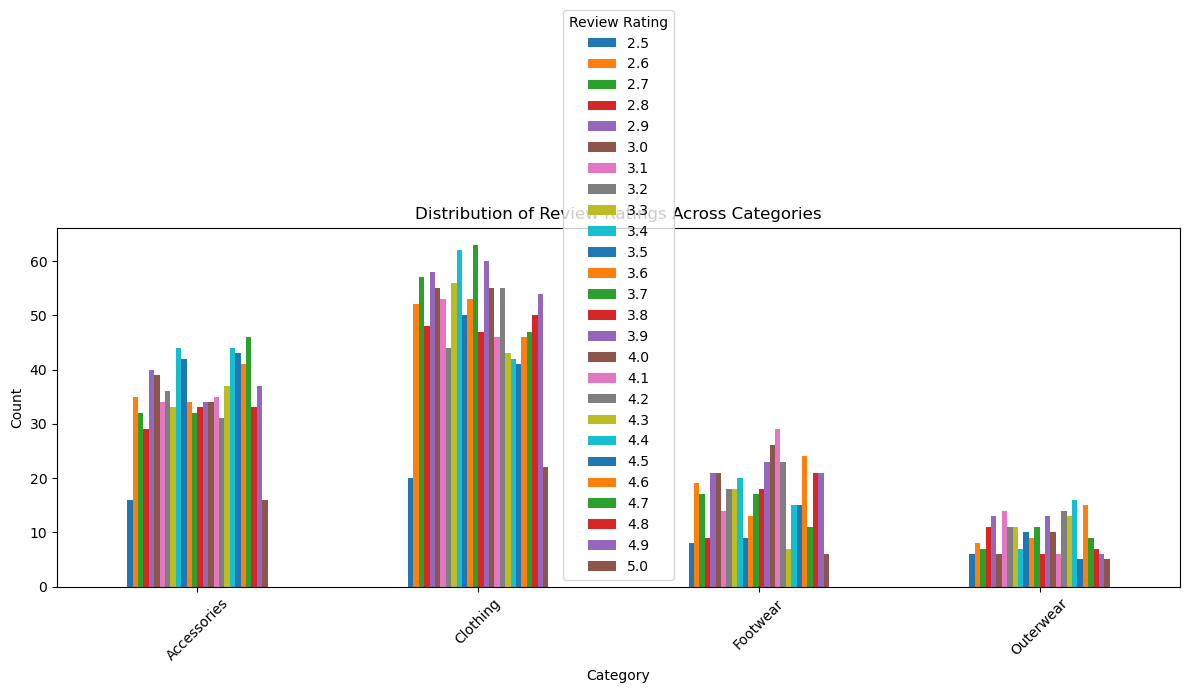

In [171]:
# Plot 1: Distribution of Review Ratings

#import pandas as pd
#import matplotlib.pyplot as plt

#Assuming your dataframe is called df

#Grouping and counting review ratings per category
rating_dist = df.groupby(['Category', 'Review Rating']).size().unstack(fill_value=0)
rating_dist.head()

#Plotting the distribution
rating_dist.plot(kind='bar', figsize=(12,6))
plt.title('Distribution of Review Ratings Across Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Review Rating', loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Next, let's explore the frequency of purchases to see how often customers shop on the platform.

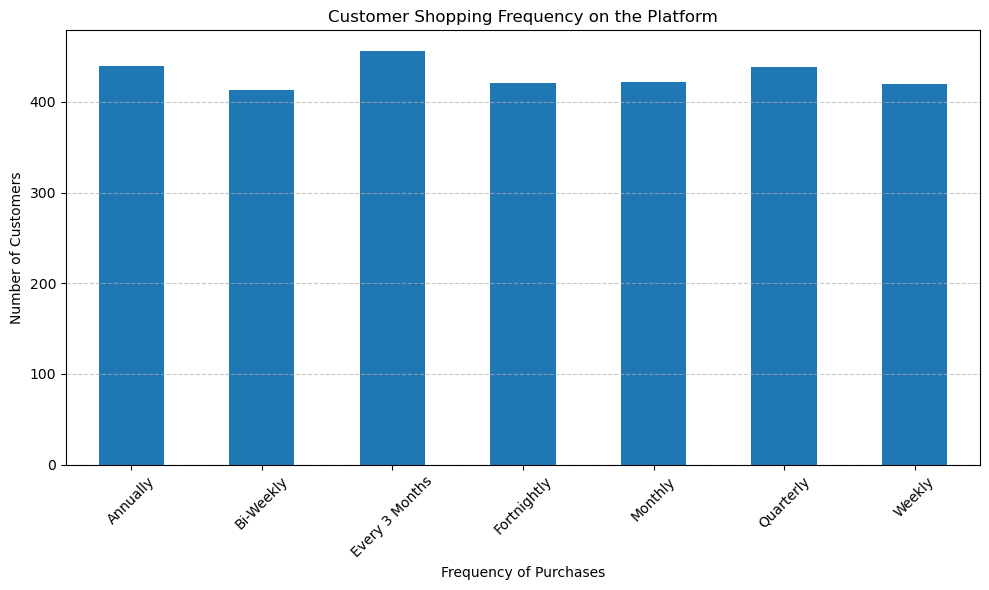

In [189]:
# Plot 2: Frequency of purchases by customers, numbers of customers who do the maximum number of purchases

import matplotlib.pyplot as plt

#Count how hoten each frequency level appears
freq_counts = df['Frequency of Purchases'].value_counts().sort_index()

#plt.figure(plot='bar', fixsize=(10,6))

# Plotting
plt.figure(figsize=(10,6))
freq_counts.plot(kind='bar')
plt.title('Customer Shopping Frequency on the Platform')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In order to improve our customer satisfaction, we need to understand the times of year when we have the highest sales and also analyze the geographic distribution of our customers. Let's find the distribution of sales over the months as well as the top 10 geographic locations with the highest number of customers.

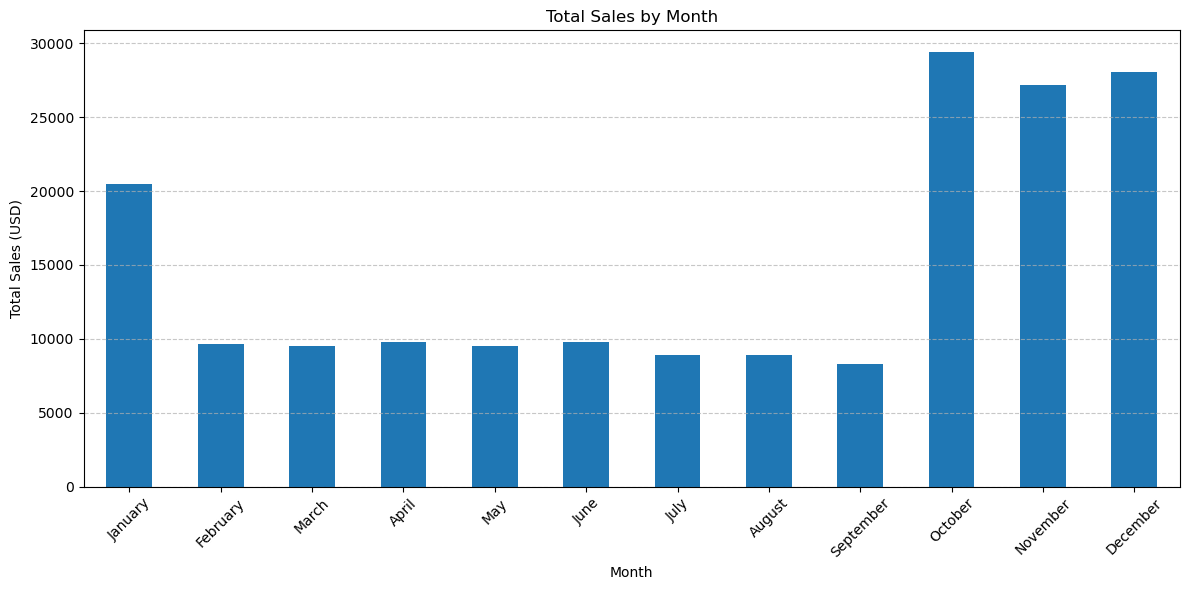

In [198]:
# Plot 3: Distribution of sales over month

import matplotlib.pyplot as plt

# Group by Month and sum the sales
monthly_sales = df.groupby('Month_Name')['Purchase Amount (USD)'].sum()

#optional: Ensure months are ordered correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)

#Plotting
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='bar')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's examine the top 10 States in terms of number of sales.  

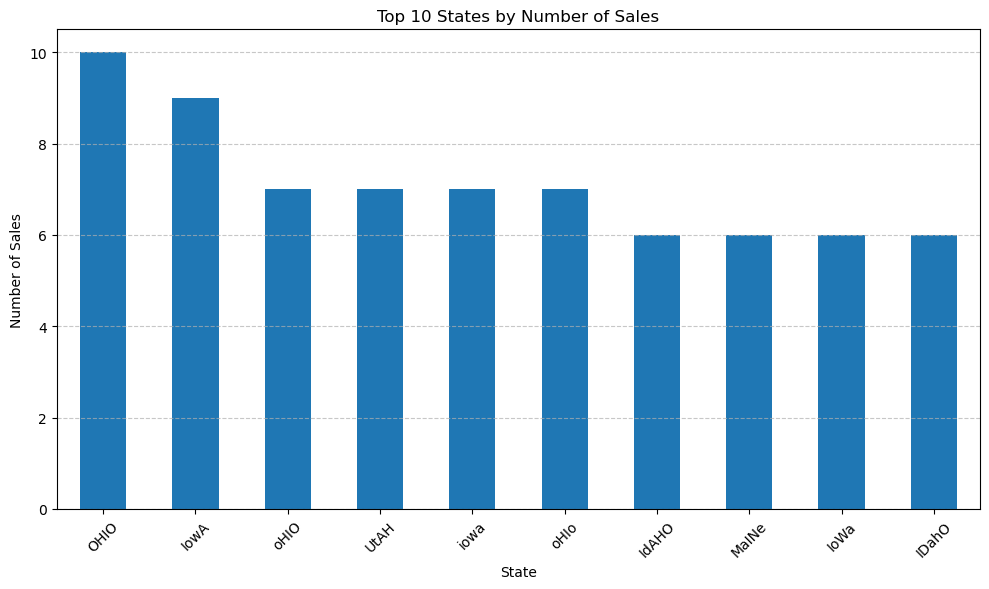

In [212]:
# Plot 4: Top 10 Geographic location of customers

import matplotlib.pyplot as plt

# Count the number of sales per state
top_states = df['Location'].value_counts().head(10)

#Plotting
plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title('Top 10 States by Number of Sales')
plt.xlabel('State')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's now analyze the data by product category, which can provide a more detailed understanding of spending habits.

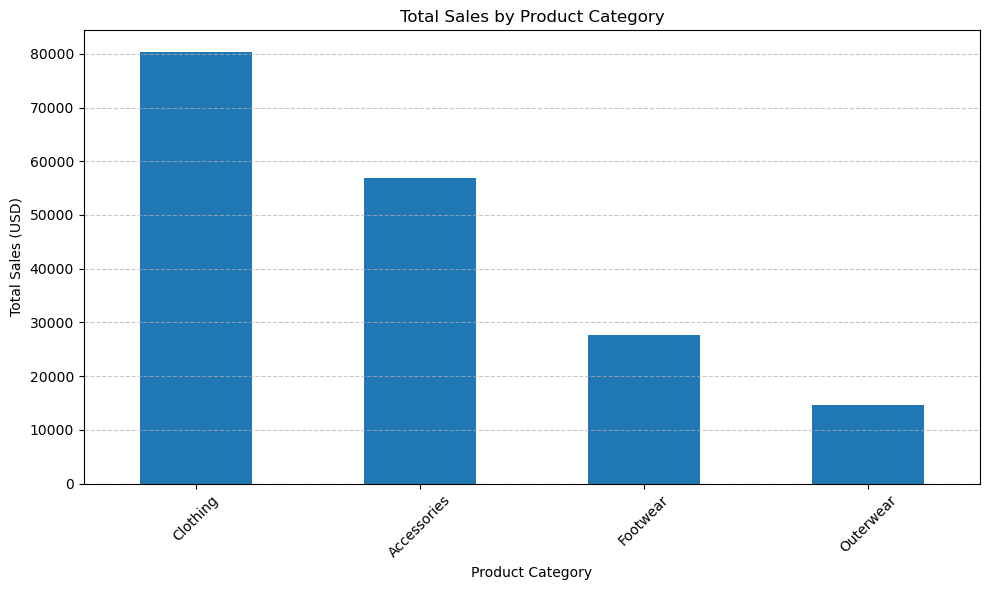

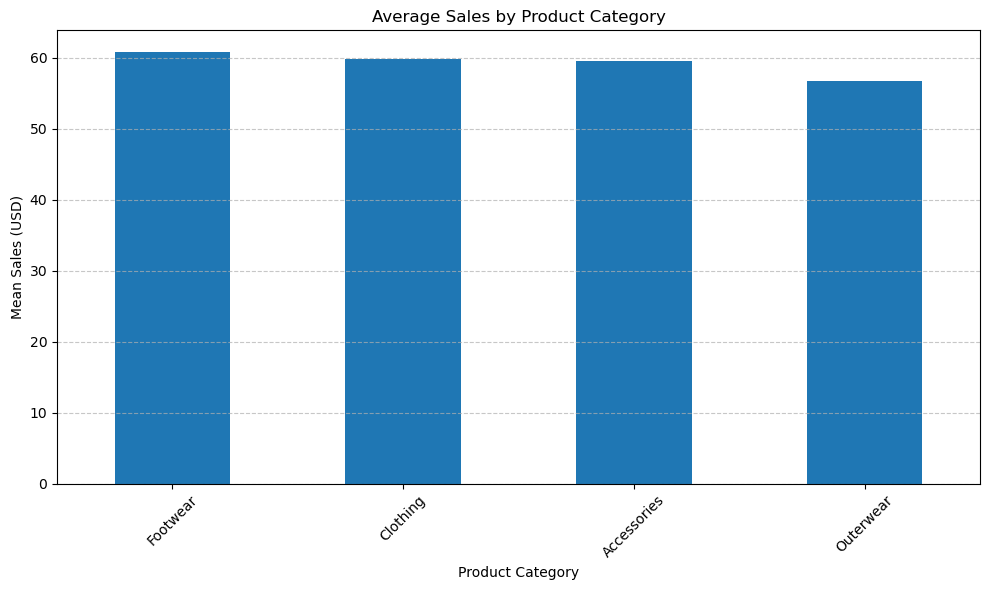

In [220]:
# Plot 5: Most purchased product categories

import matplotlib.pyplot as plt

# Grouping by Category and summing the Purchase Amount
category_sales = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

#Plotting
plt.figure(figsize=(10,6))
category_sales.plot(kind='bar')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Grouping by Category and averaging the Purchase Amount
category_sales = df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

#Plotting
plt.figure(figsize=(10,6))
category_sales.plot(kind='bar')
plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Mean Sales (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In our next and final visualization, we will look into the rating distribution across various categories. To do this, we use a specific type of chart called **Box Plot**. `plt.boxplot` creates this chart for us. To use it, we need to extract the ratings for each category and put them into a `list`.

/var/folders/09/hhph7qnd41j68t3qmft9c7fw0000gn/T/ipykernel_68971/1338166166.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ratings_by_category, labels=categories)


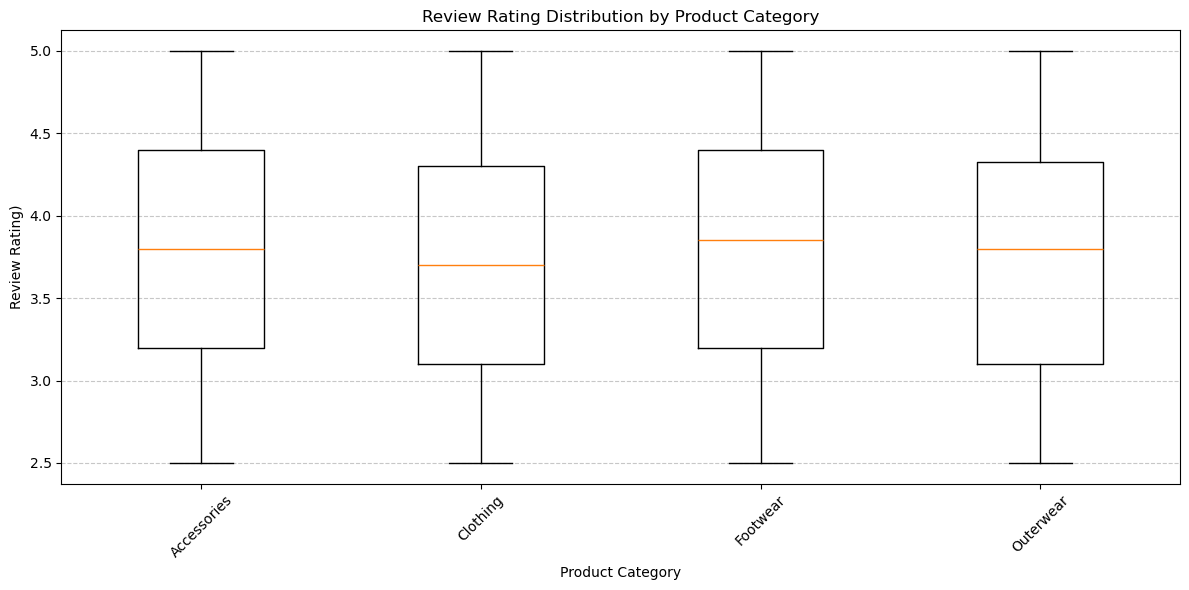

In [238]:
# Plot 6: Ratings distribution across product categories

# Get unique categories (sorted for cleaner x-axis)
categories = sorted(df['Category'].unique())

# Create a list of review rating lists, one for each category
ratings_by_category = [df[df['Category'] == category]['Review Rating'].dropna().tolist() for category in categories]

#Plotting the box plot
plt.figure(figsize=(12,6))
plt.boxplot(ratings_by_category, labels=categories)
plt.title('Review Rating Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Review Rating)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [236]:
# list comprehension 

a = [2,4,1,0,-1,-2,6,1,-3]
print(a)

#creating a for loop below
b = list()
for i in a:
    if i>=2:
        b.append(i)
print(b)

#alternative to for loop above

b = [i for i in a if i>=2]
print(b)

[2, 4, 1, 0, -1, -2, 6, 1, -3]
[2, 4, 6]
[2, 4, 6]


# Conclusions and Next Steps

In this project, we analyzed an e-commerce dataset to uncover key insights into customer purchasing behaviors. We explored product categories, review ratings, purchase frequency, and geographic distribution, gaining insights into customer preferences and engagement trends. These insights help identify which product categories are most popular, how frequently customers make purchases, and how satisfied they are with their purchases.

We found that **Clothing** and **Accessories** are the top two purchased categories, and that the review ratings across all categories are almost identical. To improve the customer experience, we now need to dive into the reviews left for each product to understand the reasons behind the low ratings. This analysis has helped us narrow down our focus to the most popular categories and locations.

Data analysts and scientists will take this analysis to the next step by creating a dashboard that displays all these metrics and charts in an interactive and dynamic report. They will perform in-depth statistical analysis to understand the factors impacting the low ratings and then create a machine learning model that can predict the rating for an item before it is released.

<div id="container" style="position:relative;">
    <div style="position:relative; float:right">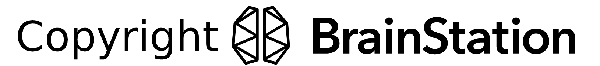
    </div>
</div>